# DASH: Diversified Aggregation of SHAP
## Experimental Validation Notebook

**Caraker, Arnold, Rhoads (2026)**

This notebook runs the core experiments validating the DASH method and explains what each result means.

### The Problem

When you train an XGBoost model on data with correlated features, the model picks *one* feature from each correlated group at each split point. Which one it picks is essentially arbitrary — feature A and feature B carry the same signal, and the model grabs whichever gives a marginal gain advantage at that specific split. Change the hyperparameters slightly and the model picks different members of the correlated group. The predictions barely change, but the SHAP values shift dramatically.

This is the Rashomon effect applied to explanations: many models fit the data equally well, but they tell completely different stories about *which features matter*.

### How DASH Works

Instead of trusting one model's arbitrary feature selection, DASH deliberately trains a population of models that are *forced* to use different features by restricting `colsample_bytree` to low values (0.1–0.5). After filtering for performance and selecting for diversity, their SHAP matrices are averaged element-wise. The consensus explanation fairly distributes importance across correlated groups rather than concentrating it on whichever member one model happened to grab.

### What We Test

1. **Correlation Sweep** — The central claim: DASH advantage grows with collinearity, including a ρ=0 safety control
2. **Overlapping Correlation** — Robustness beyond idealized block-diagonal structures
3. **Nonlinear DGP** — DASH works with complex, non-additive relationships
4. **Real Data** — California Housing (regression) and Breast Cancer (classification with heavy natural collinearity)

See `EXPERIMENT_GUIDE.md` for the full rationale behind every experimental choice.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import warnings, time

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

from dash.core.pipeline import DASHPipeline
from dash.core.consensus import compute_consensus, compute_diagnostics
from dash.core.filtering import performance_filter
from dash.core.diversity import (
    get_preliminary_importance, greedy_maxmin_selection,
    cluster_coverage_selection, deduplication_selection,
)
from dash.core.diagnostics import FeatureStabilityIndex, ImportanceStabilityPlot, local_disagreement_map
from dash.experiments.synthetic import generate_synthetic_linear, generate_synthetic_nonlinear
from dash.baselines import (
    SingleBestBaseline, LargeSingleModelBaseline, NaiveAveragingBaseline,
    StochasticRetrainBaseline, EnsembleSHAPBaseline,
)
from dash.evaluation import importance_accuracy, importance_stability, within_group_equity

SEED = 42
# Reduce M for faster iteration; paper uses M=200, K=20, N_REPS=10
M = 50
K = 15
N_REPS = 5
EPSILON = 0.03
DELTA = 0.05
feature_names = [f'G{g}_f{j}' for g in range(10) for j in range(5)]

print('DASH loaded. Config: M=%d, K=%d, reps=%d' % (M, K, N_REPS))

DASH loaded. Config: M=50, K=15, reps=5


---
## 1. Proof of Concept: Synthetic Linear DGP at ρ=0.9

50 features in 10 groups of 5, within-group correlation ρ=0.9. The target is a linear combination of group means with known coefficients descending from 2.0 to 0.0. Because the DGP is linear and symmetric within groups, we know the ground-truth importance: every feature in group g should get importance |β_g|/5.

This is the simplest possible test — if DASH doesn't work here, it won't work anywhere.

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test, groups, true_importance, meta = \
    generate_synthetic_linear(N=5000, rho=0.9, seed=SEED)

print(f"Dataset: {meta['dgp']} DGP, ρ={meta['rho']}")
print(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"  Beta groups: {meta['beta_groups']}")

# Run DASH MaxMin
dash_maxmin = DASHPipeline(
    M=M, K=K, epsilon=EPSILON, delta=DELTA,
    selection_method='maxmin', task='regression',
    n_jobs=-1, seed=SEED,
)
dash_maxmin.fit(X_train, y_train, X_val, y_val, X_ref=X_val, feature_names=feature_names)

Dataset: linear DGP, ρ=0.9
  Train: (3500, 50), Val: (750, 50), Test: (750, 50)
  Beta groups: [2.  1.5 1.  0.8 0.6 0.4 0.3 0.2 0.1 0. ]
DASH Stage 1: Population Generation
Training 50 models with -1 parallel jobs...


Training: 100%|█████████████████████████████████| 50/50 [00:09<00:00,  5.16it/s]


Population trained. Best: -0.6061, Worst: -1.5457, Mean: -0.7544

DASH Stage 2: Performance Filtering (ε=0.03)
Performance filter: 3/50 models within ε=0.03 of best (-0.6061)

DASH Stage 3: Diversity Selection (maxmin)
  Diversity threshold reached at K=2 (min_dist=0.0474 < δ=0.05)
MaxMin selection: 2 models selected from 3 candidates

DASH Stage 4: Consensus SHAP (K=2)


Computing SHAP: 100%|█████████████████████████████| 2/2 [00:08<00:00,  4.50s/it]

Consensus computed from 2 models. Top 5 features: [4, 3, 1, 0, 2]

DASH Stage 5: Stability Diagnostics

Pipeline complete in 27.0s (Training: 18.0s, SHAP: 9.0s)


### 1.1 Importance-Stability Plot

Each point is a feature, positioned by consensus importance (x) and Feature Stability Index (y). Features colored by true group membership. The four quadrants identify:

- **I: Robust Drivers** (high importance, low FSI) — features whose importance is consistent across models
- **II: Collinear Cluster Members** (high importance, high FSI) — important features whose attribution varies because they're interchangeable with correlated neighbors
- **III: Confirmed Unimportant** (low importance, low FSI) — genuinely unimportant features (group 10, β=0)
- **IV: Fragile Interactions** (low importance, high FSI) — features with unstable, small attributions

At ρ=0.9, most important features should land in quadrant II (collinear), with the FSI serving as an unsupervised collinearity detector.

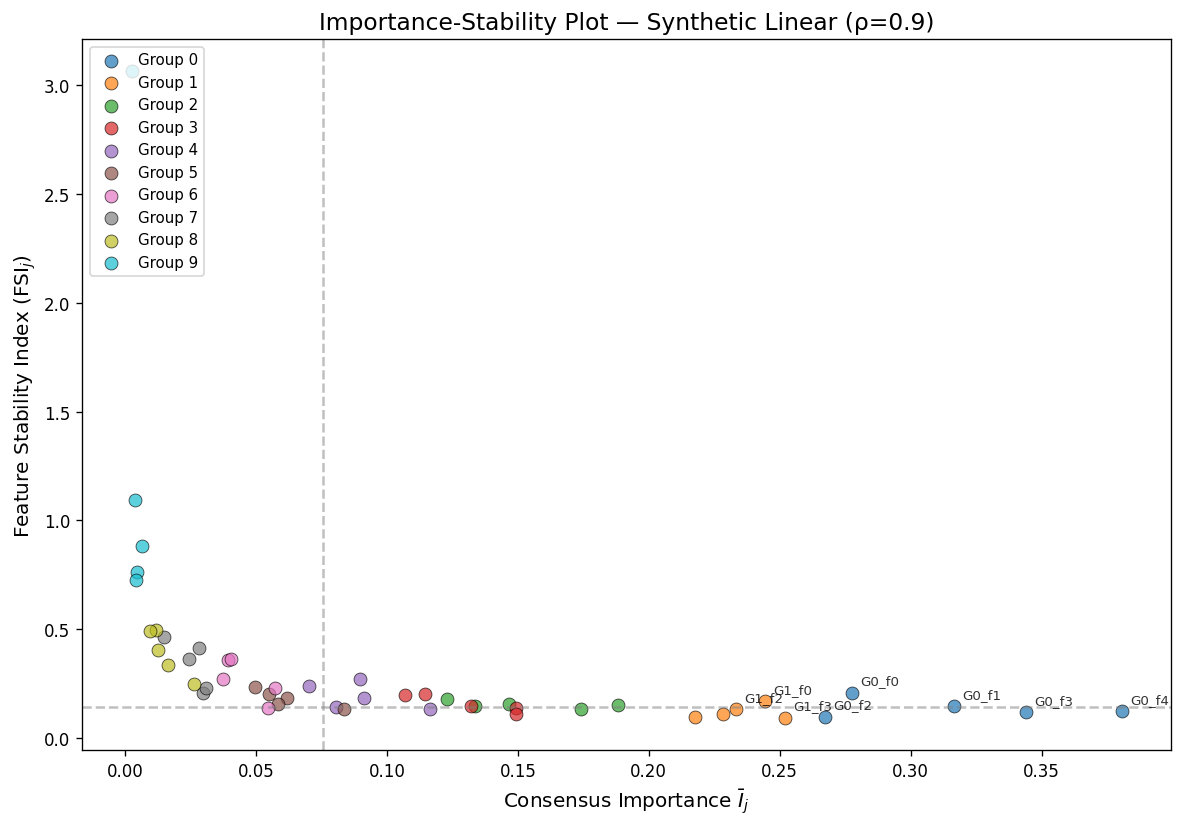

DASH (MaxMin) vs Ground Truth:
  Spearman ρ:      0.9870
  Within-group CV: 0.1939

Feature Stability Summary
Feature                Importance      FSI
----------------------------------------
G0_f4                      0.3806    0.124
G0_f3                      0.3439    0.119
G0_f1                      0.3164    0.147
G0_f0                      0.2776    0.208
G0_f2                      0.2674    0.098
G1_f3                      0.2521    0.092
G1_f0                      0.2445    0.170
G1_f2                      0.2332    0.132
G1_f4                      0.2283    0.109
G1_f1                      0.2176    0.096


In [3]:
fig = dash_maxmin.plot_importance_stability(
    groups=groups,
    title=f'Importance-Stability Plot — Synthetic Linear (ρ={meta["rho"]})',
    annotate_top_k=8,
)
plt.show()

# Accuracy and equity
rho_acc, mse_acc = importance_accuracy(dash_maxmin.global_importance_, true_importance)
equity = within_group_equity(dash_maxmin.global_importance_, groups)
print(f'DASH (MaxMin) vs Ground Truth:')
print(f'  Spearman ρ:      {rho_acc:.4f}')
print(f'  Within-group CV: {equity:.4f}')
print(f'\n{dash_maxmin.get_fsi().summary(top_k=10)}')

### 1.2 Local Disagreement Map

For the observation with the highest cross-model SHAP variance, this shows the consensus attribution (bar) and ±1 std uncertainty (error bars) for each feature. Wide error bars = the explanation depends on which model you ask. Narrow bars = all models agree. This is directly useful in practice: you can identify *which parts of an individual prediction's explanation are reliable* versus model-specification-dependent.

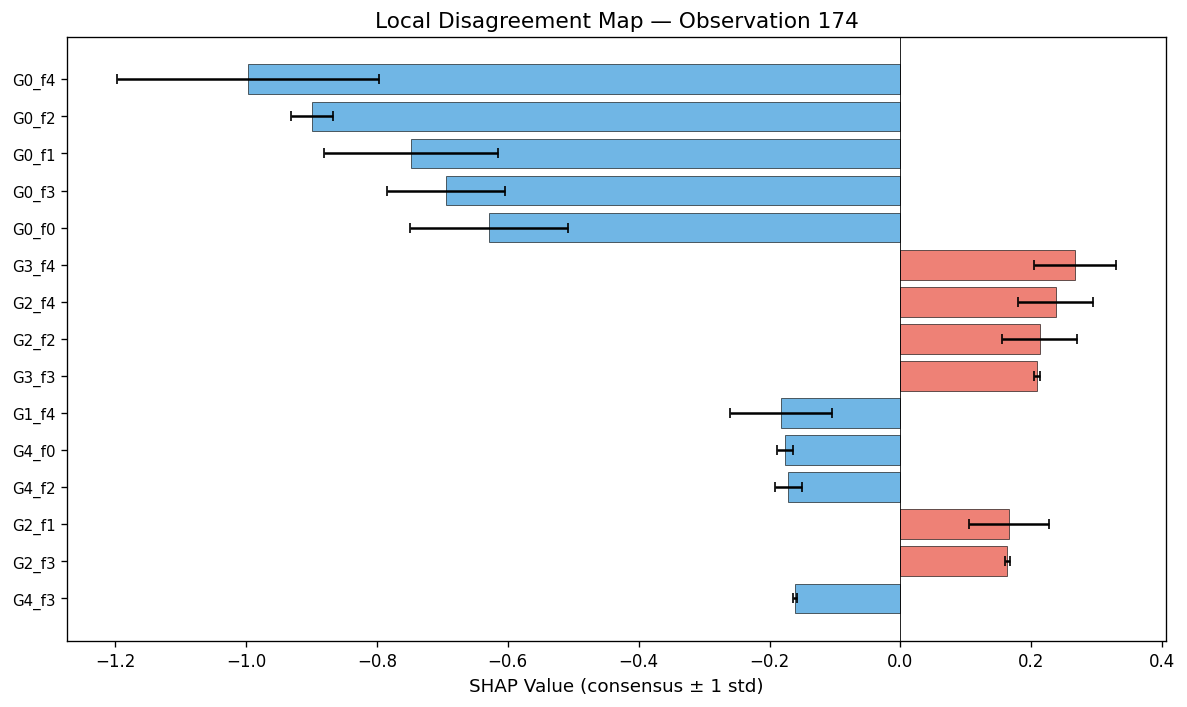

In [4]:
variance_per_obs = np.mean(dash_maxmin.variance_matrix_, axis=1)
high_disagreement_idx = np.argmax(variance_per_obs)
fig = local_disagreement_map(
    dash_maxmin.all_shap_matrices_, high_disagreement_idx,
    feature_names=feature_names, top_k=15,
)
plt.show()

---
## 2. Full Baseline Comparison at ρ=0.9

Now we compare all 7 methods. Each tests a specific hypothesis:

| Method | What it tests |
|--------|---------------|
| **Single Best** | Standard practice (baseline to beat) |
| **Large Single Model** | Single XGBoost with same low colsample_bytree as DASH but K×T total trees. Tests the sequential residual dependency hypothesis: does DASH's advantage require independent models, or does internal tree diversity suffice? |
| **Ensemble SHAP** | Paillard et al. (2025): single large ensemble with standard high colsample_bytree. Tests whether model-level ensembling beats explanation aggregation. |
| **Naive Top-N** | Averaging without diversity selection. Tests whether diversity selection adds value beyond simple averaging. |
| **Stochastic Retrain** | Same hyperparams, different seeds. Tests whether deliberate diversification beats natural stochastic variation. |
| **DASH (Dedup)** | Minimal deduplication only. Weakest DASH variant, sanity check. |
| **DASH (MaxMin)** | Recommended default. Maximizes feature utilization diversity. |
| **DASH (Cluster)** | Uses correlation matrix for cluster coverage. Strongest when correlation structure is clean. |

In [5]:
# Reuse DASH MaxMin's population for fair comparison
models = dash_maxmin.models_
val_scores = dash_maxmin.val_scores_
filtered = dash_maxmin.filtered_indices_
imp_vecs = get_preliminary_importance(models, filtered, X_val, method='gain')
filt_scores = {i: val_scores[i] for i in filtered}

# DASH Cluster
sel_cluster = cluster_coverage_selection(imp_vecs, filt_scores, X_train, tau=0.3, K=K, verbose=False)
cons_cluster, shap_cluster = compute_consensus(models, sel_cluster, X_val, verbose=False)
_, _, fsi_cluster, imp_cluster = compute_diagnostics(shap_cluster)

# DASH Dedup
sel_dedup = deduplication_selection(imp_vecs, filt_scores, rho_threshold=0.95, verbose=False)
if len(sel_dedup) > K:
    sel_dedup = sorted(sel_dedup, key=lambda i: val_scores[i], reverse=True)[:K]
cons_dedup, shap_dedup = compute_consensus(models, sel_dedup, X_val, verbose=False)
_, _, fsi_dedup, imp_dedup = compute_diagnostics(shap_dedup)

# Naive Top-N
naive = NaiveAveragingBaseline(N=K)
naive.fit_from_population(models, val_scores, X_val)

# Single Best
single = SingleBestBaseline(n_trials=50, task='regression', seed=SEED)
single.fit(X_train, y_train, X_val, y_val, X_ref=X_val)

# Large Single Model (sequential residual dependency test)
lsm = LargeSingleModelBaseline(K=K, T_per_model=500, colsample_bytree=0.2, seed=SEED)
lsm.fit(X_train, y_train, X_val, y_val, X_ref=X_val)

# Ensemble SHAP (Paillard baseline)
ensemble = EnsembleSHAPBaseline(n_estimators=2000, task='regression', seed=SEED)
ensemble.fit(X_train, y_train, X_val, y_val, X_ref=X_val)

# Stochastic Retrain
stochastic = StochasticRetrainBaseline(N=K, task='regression', n_jobs=-1, seed=SEED)
stochastic.fit(X_train, y_train, X_val, y_val, X_ref=X_val)

# Results table
methods = {
    'Single Best': single.global_importance_,
    'Large Single Model': lsm.global_importance_,
    'Ensemble SHAP': ensemble.global_importance_,
    'Naive Top-N': naive.global_importance_,
    'Stochastic Retrain': stochastic.global_importance_,
    'DASH (Dedup)': imp_dedup,
    'DASH (MaxMin)': dash_maxmin.global_importance_,
    'DASH (Cluster)': imp_cluster,
}

print(f'{"Method":<20} {"Spearman ρ":>12} {"MSE":>10} {"Within-Group CV":>16}')
print('=' * 60)
for name, imp in methods.items():
    rho, mse = importance_accuracy(imp, true_importance)
    eq = within_group_equity(imp, groups)
    print(f'{name:<20} {rho:>12.4f} {mse:>10.6f} {eq:>16.4f}')

 96%|=================== | 718/750 [00:23<00:01]       

Method                 Spearman ρ        MSE  Within-Group CV
Single Best                0.9860   0.000011           0.1950
Large Single Model         0.9479   0.000109           0.3544
Ensemble SHAP              0.9831   0.000031           0.2389
Naive Top-N                0.9899   0.000009           0.2025
Stochastic Retrain         0.9860   0.000011           0.2297
DASH (Dedup)               0.9870   0.000009           0.1956
DASH (MaxMin)              0.9870   0.000012           0.1939
DASH (Cluster)             0.9875   0.000014           0.1955


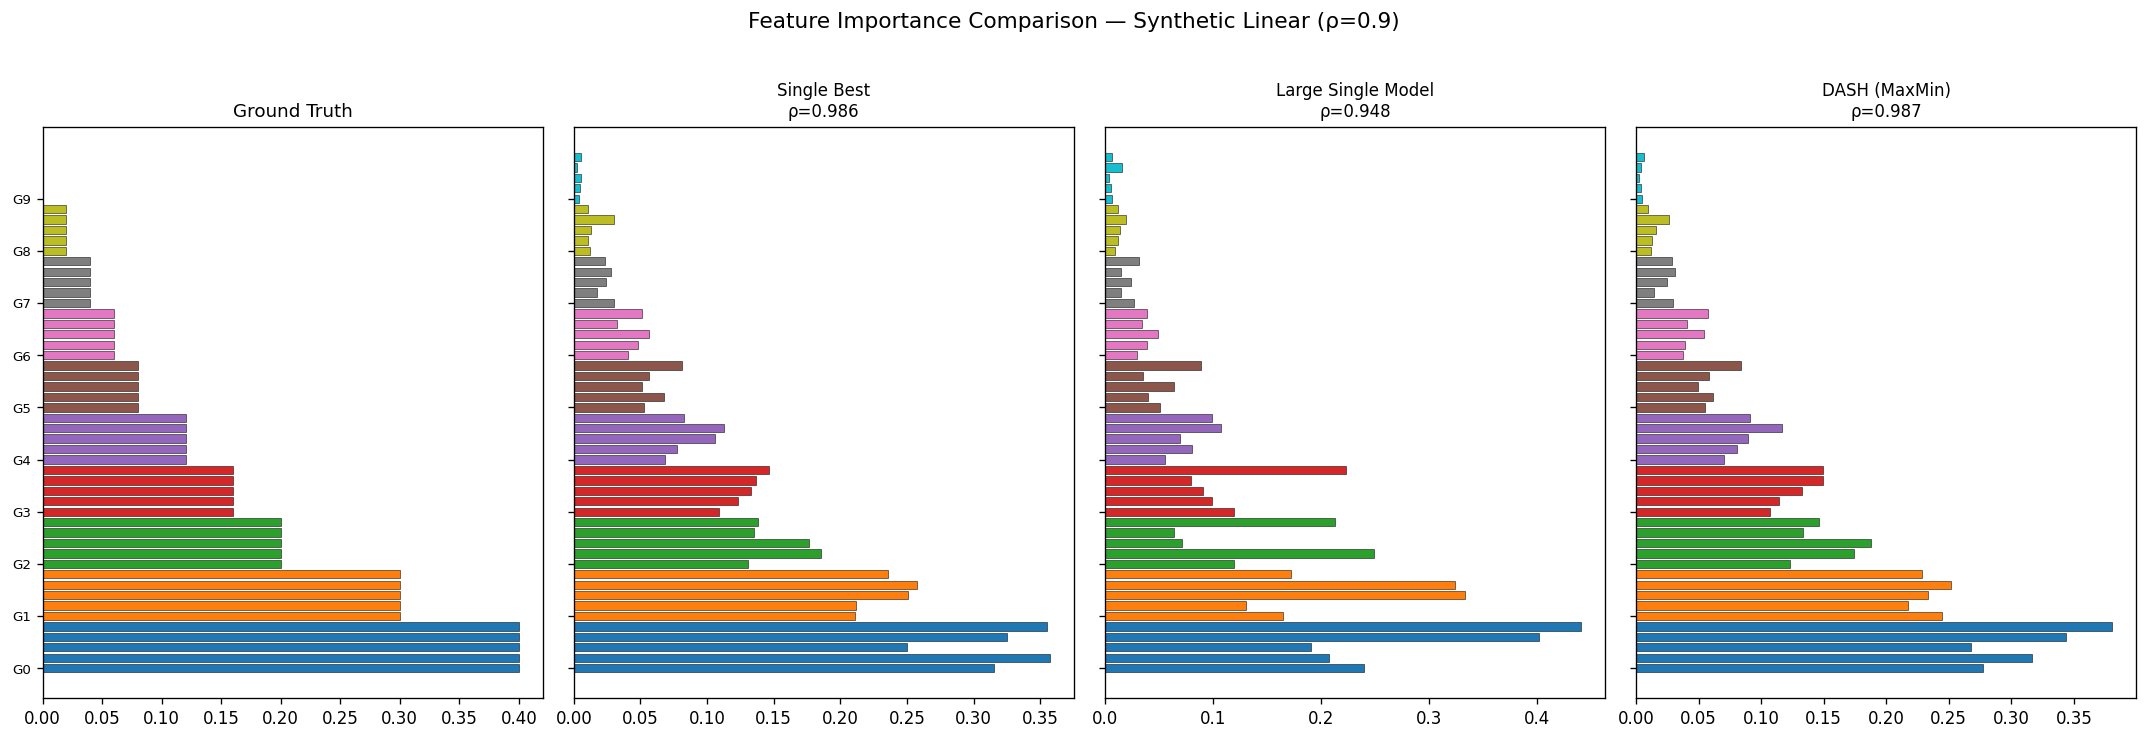

In [6]:
# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
group_colors = plt.cm.tab10(groups / groups.max())

for ax_idx, (name, imp) in enumerate([('Ground Truth', true_importance),
                                       ('Single Best', single.global_importance_),
                                       ('Large Single Model', lsm.global_importance_),
                                       ('DASH (MaxMin)', dash_maxmin.global_importance_)]):
    axes[ax_idx].barh(range(50), imp, color=group_colors, edgecolor='k', linewidth=0.3)
    if name != 'Ground Truth':
        rho, _ = importance_accuracy(imp, true_importance)
        axes[ax_idx].set_title(f'{name}\nρ={rho:.3f}', fontsize=10)
    else:
        axes[ax_idx].set_title(name, fontsize=11)
    axes[ax_idx].invert_yaxis()
    if ax_idx == 0:
        axes[ax_idx].set_yticks(range(0, 50, 5))
        axes[ax_idx].set_yticklabels([f'G{g}' for g in range(10)], fontsize=8)

fig.suptitle(f'Feature Importance Comparison — Synthetic Linear (ρ=0.9)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 3. Stability Across Repetitions

A single run's accuracy tells you if the method got the right answer *this time*. Stability tells you if it gives the *same* answer every time. We run 5 repetitions with different random seeds (regenerating data each time) and measure the mean pairwise Spearman correlation between importance rankings across runs.

This is the headline metric. A method with high accuracy but low stability is useless in practice — you can't trust any individual run's output.

In [7]:
method_names = ['Single Best', 'Large Single Model', 'Naive Top-N', 'DASH (MaxMin)', 'DASH (Cluster)']
stability_vectors = {n: [] for n in method_names}
accuracy_vectors = {n: [] for n in method_names}
equity_vectors = {n: [] for n in method_names}

for rep in range(N_REPS):
    rep_seed = SEED + rep
    print(f'\nRepetition {rep + 1}/{N_REPS} (seed={rep_seed})')

    Xtr, ytr, Xv, yv, _, _, grps, true_imp, _ = \
        generate_synthetic_linear(N=5000, rho=0.9, seed=rep_seed)

    # Single Best
    sb = SingleBestBaseline(n_trials=30, seed=rep_seed)
    sb.fit(Xtr, ytr, Xv, yv, X_ref=Xv)
    stability_vectors['Single Best'].append(sb.global_importance_)
    r, _ = importance_accuracy(sb.global_importance_, true_imp)
    accuracy_vectors['Single Best'].append(r)
    equity_vectors['Single Best'].append(within_group_equity(sb.global_importance_, grps))

    # Large Single Model (sequential residual dependency test)
    lsm_ = LargeSingleModelBaseline(K=K, T_per_model=500, colsample_bytree=0.2, seed=rep_seed)
    lsm_.fit(Xtr, ytr, Xv, yv, X_ref=Xv)
    stability_vectors['Large Single Model'].append(lsm_.global_importance_)
    r, _ = importance_accuracy(lsm_.global_importance_, true_imp)
    accuracy_vectors['Large Single Model'].append(r)
    equity_vectors['Large Single Model'].append(within_group_equity(lsm_.global_importance_, grps))

    # DASH MaxMin
    dm = DASHPipeline(M=M, K=K, epsilon=EPSILON, delta=DELTA,
                      selection_method='maxmin', n_jobs=-1, seed=rep_seed, verbose=False)
    dm.fit(Xtr, ytr, Xv, yv, X_ref=Xv, feature_names=feature_names)
    stability_vectors['DASH (MaxMin)'].append(dm.global_importance_)
    r, _ = importance_accuracy(dm.global_importance_, true_imp)
    accuracy_vectors['DASH (MaxMin)'].append(r)
    equity_vectors['DASH (MaxMin)'].append(within_group_equity(dm.global_importance_, grps))

    # DASH Cluster (reuse population)
    iv = get_preliminary_importance(dm.models_, dm.filtered_indices_, Xv, method='gain')
    fs = {i: dm.val_scores_[i] for i in dm.filtered_indices_}
    sc = cluster_coverage_selection(iv, fs, Xtr, tau=0.3, K=K, verbose=False)
    cc, sc_ = compute_consensus(dm.models_, sc, Xv, verbose=False)
    _, _, _, ic = compute_diagnostics(sc_)
    stability_vectors['DASH (Cluster)'].append(ic)
    r, _ = importance_accuracy(ic, true_imp)
    accuracy_vectors['DASH (Cluster)'].append(r)
    equity_vectors['DASH (Cluster)'].append(within_group_equity(ic, grps))

    # Naive Top-N (reuse population)
    nv = NaiveAveragingBaseline(N=K)
    nv.fit_from_population(dm.models_, dm.val_scores_, Xv)
    stability_vectors['Naive Top-N'].append(nv.global_importance_)
    r, _ = importance_accuracy(nv.global_importance_, true_imp)
    accuracy_vectors['Naive Top-N'].append(r)
    equity_vectors['Naive Top-N'].append(within_group_equity(nv.global_importance_, grps))

print('\nDone.')


Repetition 1/5 (seed=42)


 98%|===================| 732/750 [00:24<00:00]        


Repetition 2/5 (seed=43)


 94%|=================== | 708/750 [00:16<00:00]       


Repetition 3/5 (seed=44)


...


Repetition 4/5 (seed=45)


 97%|=================== | 724/750 [00:13<00:00]       


Repetition 5/5 (seed=46)


 98%|===================| 737/750 [00:26<00:00]        


Done.


In [8]:
print(f'{"Method":<20} {"Stability":>10} {"Accuracy (ρ)":>14} {"Equity (CV)":>14}')
print('=' * 60)
for name in method_names:
    stab = importance_stability(stability_vectors[name])
    acc = np.mean(accuracy_vectors[name])
    eq = np.mean(equity_vectors[name])
    print(f'{name:<20} {stab:>10.4f} {acc:>14.4f} {eq:>14.4f}')

Method                Stability   Accuracy (ρ)    Equity (CV)
Single Best              0.9627         0.9814         0.2224
Large Single Model       0.9194         0.9609         0.2739
Naive Top-N              0.9764         0.9881         0.1786
DASH (MaxMin)            0.9664         0.9824         0.2109
DASH (Cluster)           0.9761         0.9879         0.1760


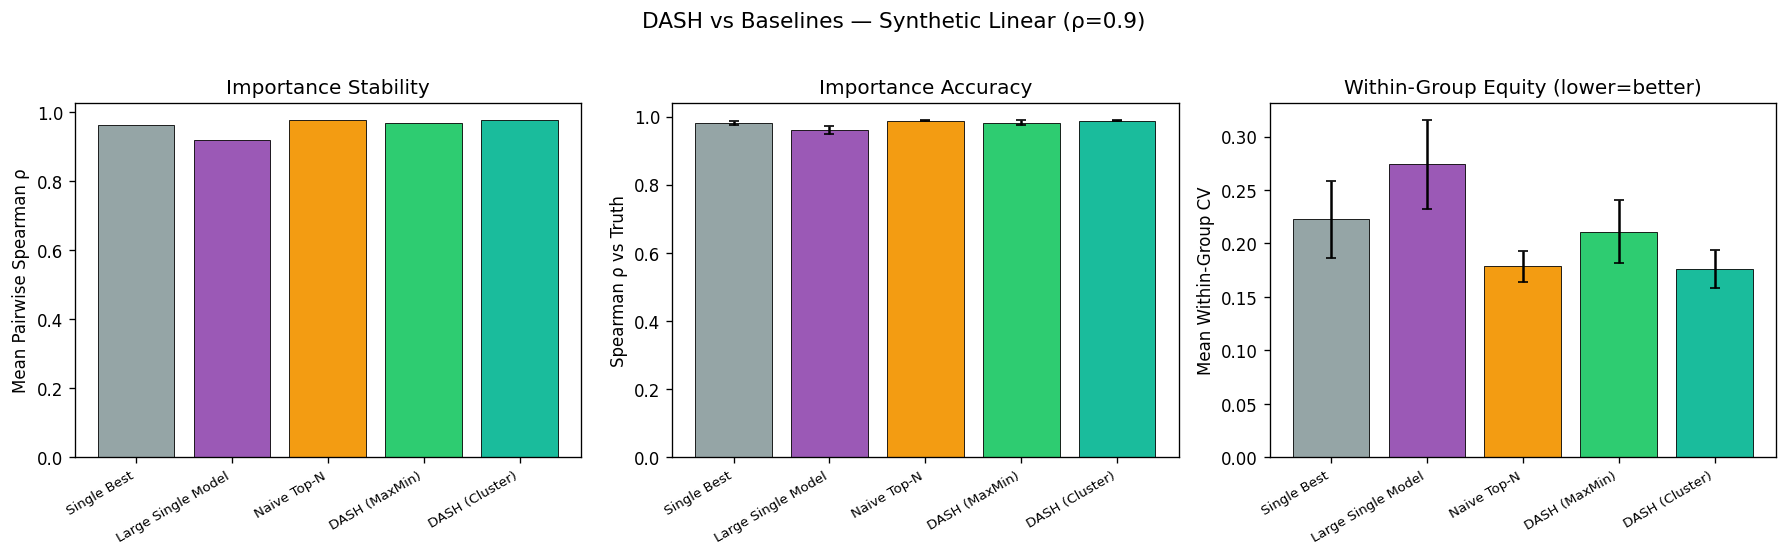

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ['#95a5a6', '#9b59b6', '#f39c12', '#2ecc71', '#1abc9c']

stab_vals = [importance_stability(stability_vectors[n]) for n in method_names]
axes[0].bar(range(len(method_names)), stab_vals, color=colors, edgecolor='k', linewidth=0.5)
axes[0].set_xticks(range(len(method_names)))
axes[0].set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Pairwise Spearman ρ')
axes[0].set_title('Importance Stability')

acc_vals = [np.mean(accuracy_vectors[n]) for n in method_names]
acc_stds = [np.std(accuracy_vectors[n]) for n in method_names]
axes[1].bar(range(len(method_names)), acc_vals, yerr=acc_stds, color=colors,
            edgecolor='k', linewidth=0.5, capsize=3)
axes[1].set_xticks(range(len(method_names)))
axes[1].set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Spearman ρ vs Truth')
axes[1].set_title('Importance Accuracy')

eq_vals = [np.mean(equity_vectors[n]) for n in method_names]
eq_stds = [np.std(equity_vectors[n]) for n in method_names]
axes[2].bar(range(len(method_names)), eq_vals, yerr=eq_stds, color=colors,
            edgecolor='k', linewidth=0.5, capsize=3)
axes[2].set_xticks(range(len(method_names)))
axes[2].set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
axes[2].set_ylabel('Mean Within-Group CV')
axes[2].set_title('Within-Group Equity (lower=better)')

fig.suptitle('DASH vs Baselines — Synthetic Linear (ρ=0.9)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 4. Correlation Sweep: ρ ∈ {0.0, 0.5, 0.7, 0.9, 0.95}

This is the paper's central figure. We sweep across collinearity levels and track how each method degrades.

**ρ=0.0 (no collinearity)** is the safety control: DASH should perform comparably to Single Best here. If it were significantly worse, it would mean the method introduces noise when there's no problem to solve.

**ρ=0.9 and ρ=0.95** are where DASH should dominate. Single Best stability degrades sharply because small hyperparameter changes cause large shifts in which features get selected.

The Large Single Model baseline is the critical comparison. It uses the *same low colsample_bytree* as DASH — so it has internal tree diversity — but trains a single sequential ensemble. Within that ensemble, early trees pick a correlated feature, modify the residuals, and bias all subsequent trees toward that same feature (the "first mover" effect). DASH breaks this sequential dependency by training independent models from scratch.

In [ ]:
rho_levels = [0.0, 0.5, 0.7, 0.9, 0.95]
sweep_methods = ['Single Best', 'Large Single Model', 'DASH (MaxMin)']
sweep_results = {rho: {} for rho in rho_levels}

for rho in rho_levels:
    print(f'\n--- ρ = {rho} ---')
    for name in sweep_methods:
        acc_runs, eq_runs, imp_runs = [], [], []
        for rep in range(N_REPS):
            rep_seed = SEED + rep
            Xtr, ytr, Xv, yv, _, _, grps, true_imp, _ = \
                generate_synthetic_linear(N=5000, rho=rho, seed=rep_seed)

            if name == 'Single Best':
                m = SingleBestBaseline(n_trials=30, seed=rep_seed)
                m.fit(Xtr, ytr, Xv, yv, X_ref=Xv)
                imp = m.global_importance_
            elif name == 'Large Single Model':
                m = LargeSingleModelBaseline(K=K, T_per_model=500, colsample_bytree=0.2, seed=rep_seed)
                m.fit(Xtr, ytr, Xv, yv, X_ref=Xv)
                imp = m.global_importance_
            else:  # DASH MaxMin
                m = DASHPipeline(M=M, K=K, epsilon=EPSILON, delta=DELTA,
                                selection_method='maxmin', n_jobs=-1,
                                seed=rep_seed, verbose=False)
                m.fit(Xtr, ytr, Xv, yv, X_ref=Xv, feature_names=feature_names)
                imp = m.global_importance_

            r, _ = importance_accuracy(imp, true_imp)
            acc_runs.append(r)
            eq_runs.append(within_group_equity(imp, grps))
            imp_runs.append(imp)

        stab = importance_stability(imp_runs)
        sweep_results[rho][name] = {
            'stability': stab,
            'accuracy_mean': np.mean(acc_runs), 'accuracy_std': np.std(acc_runs),
            'equity_mean': np.mean(eq_runs), 'equity_std': np.std(eq_runs),
        }
        print(f'  {name:<20} stab={stab:.4f}  acc={np.mean(acc_runs):.4f}  eq={np.mean(eq_runs):.4f}')

print('\nSweep complete.')


--- ρ = 0.0 ---
  Single Best          stab=0.9761  acc=0.9876  eq=0.1505


100%|===================| 748/750 [00:12<00:00]        

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_sweep = {'Single Best': '#95a5a6', 'Large Single Model': '#e74c3c', 'DASH (MaxMin)': '#2ecc71'}
markers_sweep = {'Single Best': 's', 'Large Single Model': 'X', 'DASH (MaxMin)': 'o'}

for name in sweep_methods:
    c, m = colors_sweep[name], markers_sweep[name]
    vals = [sweep_results[rho][name]['stability'] for rho in rho_levels]
    axes[0].plot(rho_levels, vals, f'{m}-', color=c, label=name, linewidth=2, markersize=8)

    vals = [sweep_results[rho][name]['accuracy_mean'] for rho in rho_levels]
    errs = [sweep_results[rho][name]['accuracy_std'] for rho in rho_levels]
    axes[1].errorbar(rho_levels, vals, yerr=errs, fmt=f'{m}-', color=c, label=name, linewidth=2, markersize=8, capsize=3)

    vals = [sweep_results[rho][name]['equity_mean'] for rho in rho_levels]
    errs = [sweep_results[rho][name]['equity_std'] for rho in rho_levels]
    axes[2].errorbar(rho_levels, vals, yerr=errs, fmt=f'{m}-', color=c, label=name, linewidth=2, markersize=8, capsize=3)

axes[0].set_xlabel('Within-Group Correlation ρ'); axes[0].set_ylabel('Stability'); axes[0].set_title('Stability vs. Collinearity'); axes[0].legend()
axes[1].set_xlabel('Within-Group Correlation ρ'); axes[1].set_ylabel('Spearman ρ vs Truth'); axes[1].set_title('Accuracy vs. Collinearity')
axes[2].set_xlabel('Within-Group Correlation ρ'); axes[2].set_ylabel('Within-Group CV'); axes[2].set_title('Equity vs. Collinearity (lower=better)')
fig.suptitle('Correlation Sweep — DASH vs Baselines', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 5. Real Data: Breast Cancer (Heavy Natural Collinearity)

30 features where radius, perimeter, and area are essentially measuring the same thing (area ∝ perimeter² ∝ radius²). Mean, standard error, and worst-case versions of each measurement are correlated. This is the ideal showcase for DASH.

On the IS Plot, features like "mean radius" and "mean perimeter" should land in the **Collinear Cluster Members** quadrant (high importance, high FSI), while features capturing distinct geometric properties like "mean concavity" should be **Robust Drivers** (high importance, low FSI). The FSI is performing unsupervised collinearity detection — no one told it which features are correlated.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
bc_names = list(bc.feature_names)

corr_bc = np.abs(np.corrcoef(X_bc.T))
n_high = (np.sum(corr_bc > 0.9) - len(bc_names)) // 2
print(f'{len(bc_names)} features, {n_high} pairs with |r|>0.9')

Xtr, Xte, ytr, yte = train_test_split(X_bc, y_bc, test_size=0.2, random_state=SEED)
Xtr, Xv, ytr, yv = train_test_split(Xtr, ytr, test_size=0.2, random_state=SEED)
scaler = StandardScaler().fit(Xtr)
Xtr, Xv, Xte = scaler.transform(Xtr), scaler.transform(Xv), scaler.transform(Xte)

dash_bc = DASHPipeline(M=M, K=K, epsilon=0.02, delta=DELTA,
                       selection_method='maxmin', task='binary',
                       n_jobs=-1, seed=SEED)
dash_bc.fit(Xtr, ytr, Xv, yv, X_ref=Xv, feature_names=bc_names)

In [ ]:
fig = dash_bc.plot_importance_stability(
    title='IS Plot — Breast Cancer (Binary Classification)',
    annotate_top_k=8, figsize=(11, 7),
)
plt.show()
print(dash_bc.get_fsi().summary(top_k=10))

### Local Disagreement Map

For the patient with the highest cross-model explanation variance, this shows which features have reliable attributions (small error bars) and which are model-specification-dependent (large error bars). Clinically: "for this patient, texture and concavity are driving the prediction (reliable), but the specific contribution of radius vs. perimeter is uncertain (they're interchangeable)."

In [ ]:
var_obs = np.mean(dash_bc.variance_matrix_, axis=1)
fig = local_disagreement_map(
    dash_bc.all_shap_matrices_, np.argmax(var_obs),
    feature_names=bc_names, top_k=12,
)
plt.show()

---
## 6. Success Criteria

The paper defines four success criteria. Let's check them.

In [ ]:
print('SUCCESS CRITERIA')
print('=' * 60)

# 1. Stability: DASH > Single Best on >=80% of rho levels
n_wins = sum(1 for rho in rho_levels
             if sweep_results[rho]['DASH (MaxMin)']['stability']
             > sweep_results[rho]['Single Best']['stability'])
print(f'1. Stability wins: {n_wins}/{len(rho_levels)} '
      f'({"PASS" if n_wins >= 4 else "FAIL"}, need >=80%)')

# 2. Accuracy at rho=0.9
acc_09 = sweep_results[0.9]['DASH (MaxMin)']['accuracy_mean']
print(f'2. Accuracy at ρ=0.9: {acc_09:.4f} '
      f'({"PASS" if acc_09 >= 0.90 else "check"}, target >=0.90)')

# 3. Equity: DASH < Single Best at all rho
n_eq = sum(1 for rho in rho_levels
           if sweep_results[rho]['DASH (MaxMin)']['equity_mean']
           < sweep_results[rho]['Single Best']['equity_mean'])
print(f'3. Equity wins: {n_eq}/{len(rho_levels)} '
      f'({"PASS" if n_eq >= 4 else "check"}, need all or most)')

# 4. rho=0 control: DASH doesn't hurt
d0 = sweep_results[0.0]['DASH (MaxMin)']['accuracy_mean']
s0 = sweep_results[0.0]['Single Best']['accuracy_mean']
print(f'4. ρ=0 control: DASH acc={d0:.4f}, SB acc={s0:.4f}, '
      f'gap={abs(d0-s0):.4f} ({"PASS" if abs(d0-s0) < 0.1 else "check"}, need <0.1)')